# Perturbation results

Plots from saved results.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import MaxNLocator
from IPython.display import display
DATASET = 'human_lung_cancer'
cwd = Path.cwd().resolve()
if (cwd / "analysis_results").is_dir() and (cwd / "perturb.ipynb").is_file():
    HERE = cwd
else:
    HERE = next(p / "experiments" / DATASET / "perturb"
                for p in [cwd, *cwd.parents]
                if (p / "experiments" / DATASET / "perturb" / "analysis_results").is_dir())
DATA = HERE / "analysis_results"
OUTPUT = DATA / "figures"
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor": "#111111", "axes.facecolor": "#111111",
    "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white",
    "ytick.color": "white", "axes.edgecolor": "white", "font.family": "DejaVu Sans"})
def style_axis(ax):
    ax.set_facecolor("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color("white")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.grid(False)
def finish(fig, name):
    fig.savefig(OUTPUT / (name + ".png"), dpi=300, transparent=True, bbox_inches="tight")
    fig.patch.set_alpha(1)
    fig.patch.set_facecolor("#111111")
    plt.show()

## Expression-matched gene knockdown

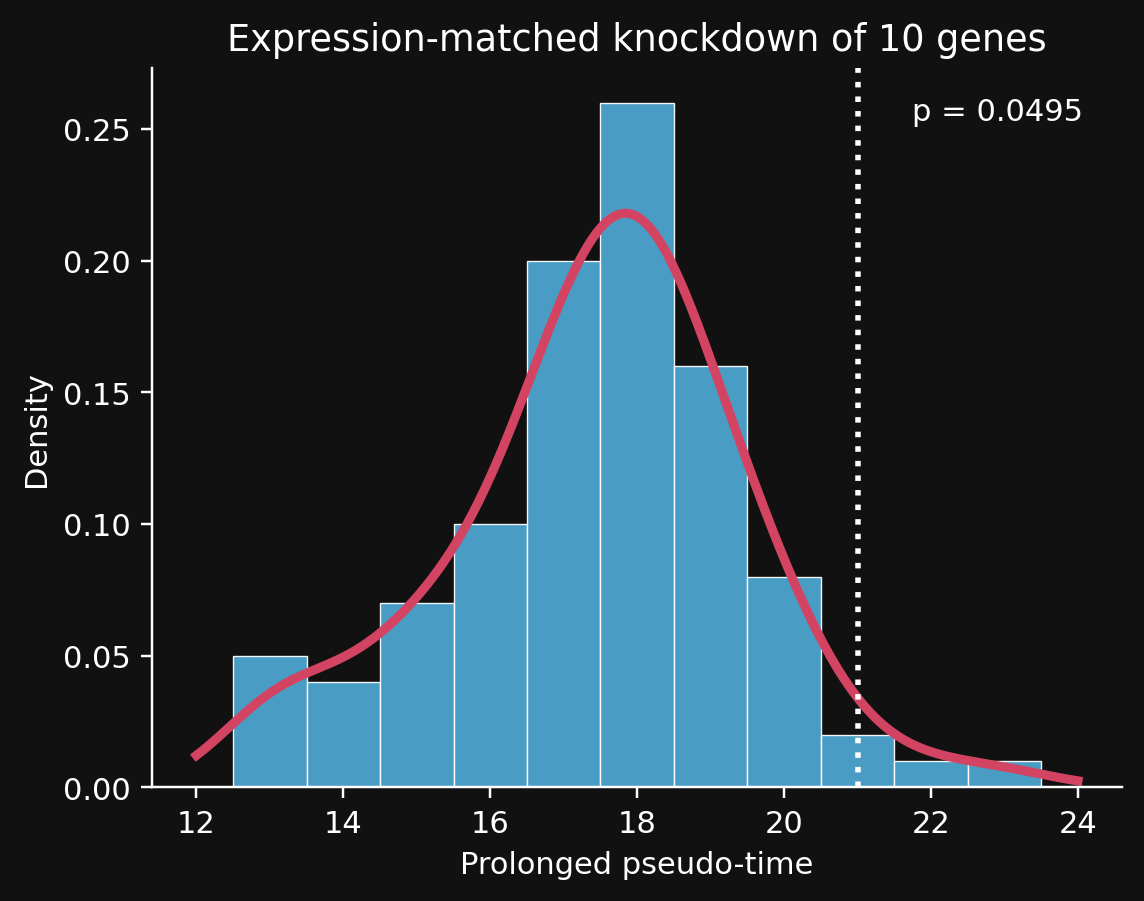

In [2]:
null = pd.read_csv(DATA / "expression_matched_null.csv")
values = null.plateau_t.to_numpy(float)
observed = 21
assert len(values) == 100
p = (np.count_nonzero(values >= observed) + 1) / (len(values) + 1)
fig, ax = plt.subplots(figsize=(5.3, 4.2), dpi=220)
# One bin per integer pseudo-time; these reproduce the saved reference histogram.
bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
ax.hist(values, bins=bins, density=True, color="#4DA6CF", alpha=0.95,
        edgecolor="white", linewidth=0.45)
grid = np.linspace(values.min() - 1, values.max() + 1, 600)
ax.plot(grid, stats.gaussian_kde(values)(grid), color="#D34463", linewidth=3)
ax.axvline(observed, color="white", linestyle=":", linewidth=1.8)
ax.set(xlabel="Prolonged pseudo-time", ylabel="Density",
       title="Expression-matched knockdown of 10 genes")
ax.text(0.96, 0.96, f"p = {p:.4f}", transform=ax.transAxes,
        ha="right", va="top", color="white")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
style_axis(ax)
fig.tight_layout()
finish(fig, "expression_matched_10_genes_plateau_t_kde")

## Number of genes and knockdown strength

The five values at each gene count correspond to 20%, 40%, 60%, 80%, and 100% knockdown strength.

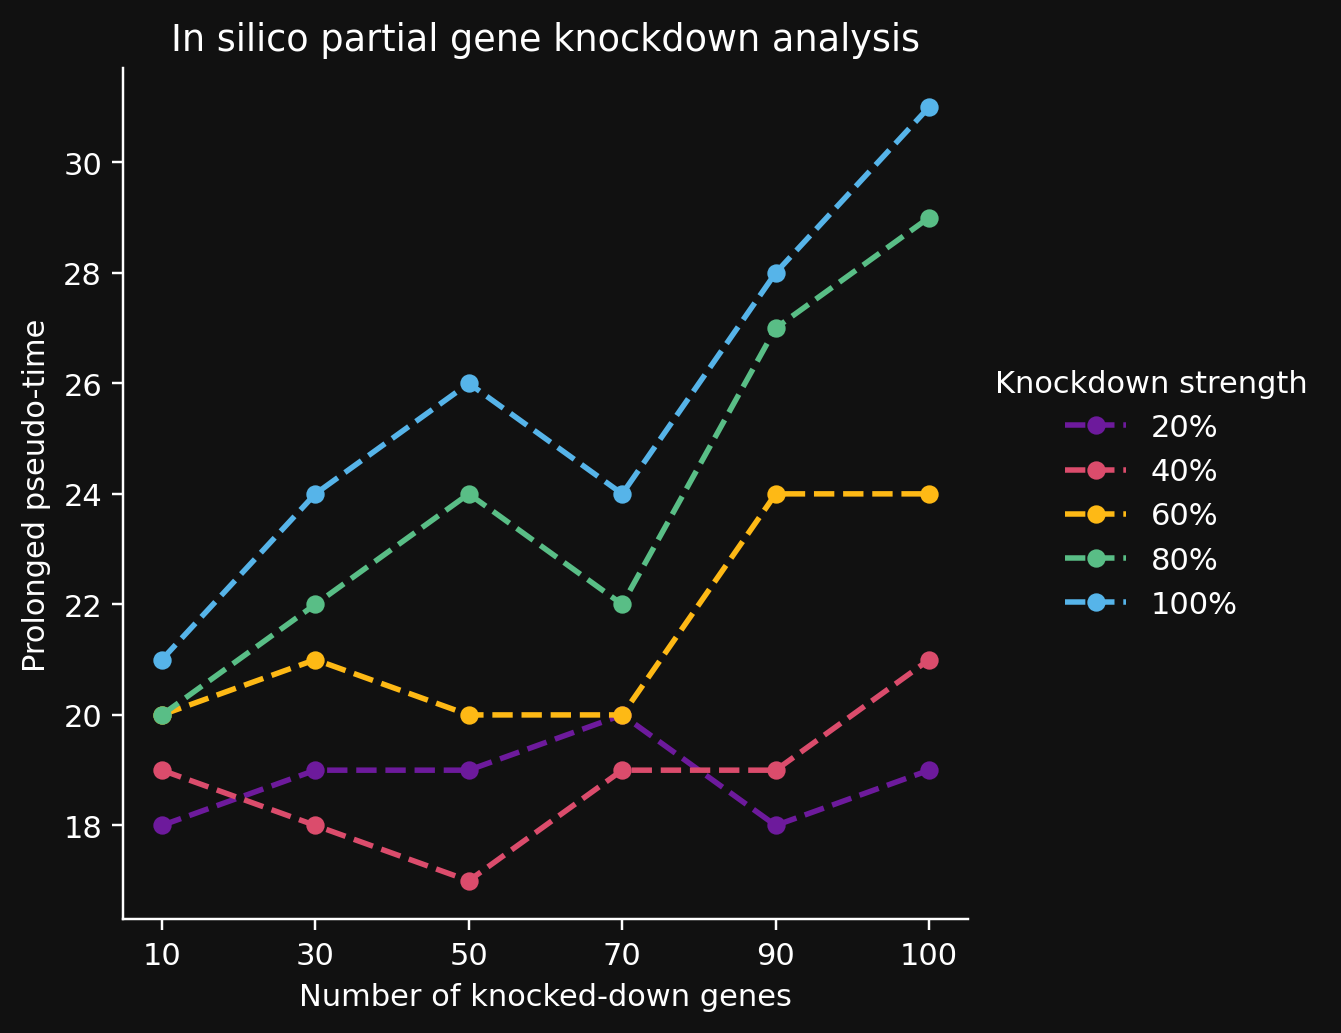

In [3]:
dose = pd.read_csv(DATA / "dose_response.csv")
counts = [10, 30, 50, 70, 90, 100]
strengths = [0.2, 0.4, 0.6, 0.8, 1.0]
palette = {0.2: "#6D1A9C", 0.4: "#DB4C6C", 0.6: "#FEB915", 0.8: "#59BE86", 1.0: "#56B4E9"}
assert dose.shape[0] == 30
assert dose.groupby("top_gene_count").size().eq(5).all()
fig, ax = plt.subplots(figsize=(6.2, 4.8), dpi=220)
for strength in strengths:
    selected = dose.loc[np.isclose(dose.knockdown_fraction, strength)].set_index("top_gene_count").loc[counts]
    ax.plot(range(len(counts)), selected.plateau_t_mean, color=palette[strength],
            linestyle="--", marker="o", linewidth=1.8, markersize=5,
            label=f"{int(strength * 100)}%")
ax.set_xticks(range(len(counts)), counts)
ax.set(xlabel="Number of knocked-down genes", ylabel="Prolonged pseudo-time",
       title="In silico partial gene knockdown analysis")
legend = ax.legend(title="Knockdown strength", loc="center left", bbox_to_anchor=(1, 0.5),
                   frameon=False)
for text in [*legend.get_texts(), legend.get_title()]:
    text.set_color("white")
style_axis(ax)
fig.tight_layout()
finish(fig, "partial_gene_knockdown_dose_response")